In [ ]:
# JupyterLite needs openpyxl to read Excel files
%pip install -q openpyxl

# What is time series data

In [80]:
import pandas as pd

In [81]:
airlines = pd.read_excel('airline_passengers.xlsx')

In [82]:
airlines.head()

,Month,Thousands of Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [83]:
airlines = airlines.set_index('Month')
airlines.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [84]:
airlines.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [85]:
airlines.loc['01 1959']

,Thousands of Passengers
Month,
1959-01-01,360


In [86]:
airlines.loc['Jan 1959']

,Thousands of Passengers
Month,
1959-01-01,360


In [87]:
airlines.loc['1959']

,Thousands of Passengers
Month,
1959-01-01,360
1959-02-01,342
1959-03-01,406
1959-04-01,396
1959-05-01,420
1959-06-01,472
1959-07-01,548
1959-08-01,559
1959-09-01,463


In [88]:
airlines.loc['06 1959': '09 1960']

,Thousands of Passengers
Month,
1959-06-01,472
1959-07-01,548
1959-08-01,559
1959-09-01,463
1959-10-01,407
1959-11-01,362
1959-12-01,405
1960-01-01,417
1960-02-01,391


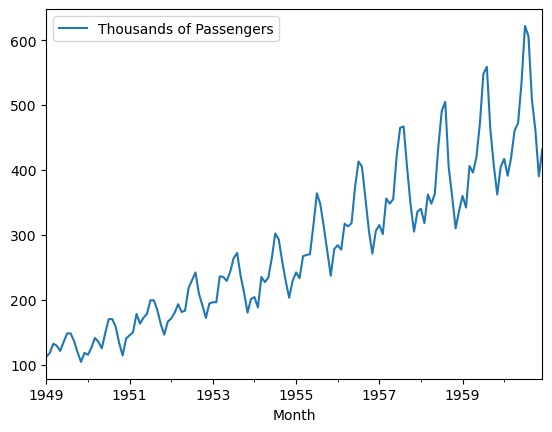

In [89]:
airlines.plot();

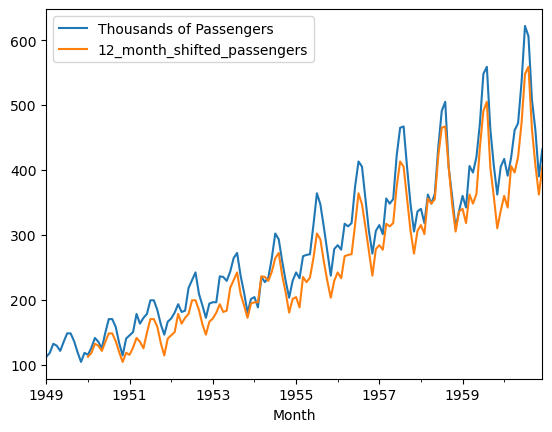

In [90]:
airlines['12_month_shifted_passengers'] = airlines['Thousands of Passengers'].shift(12)
airlines.plot();

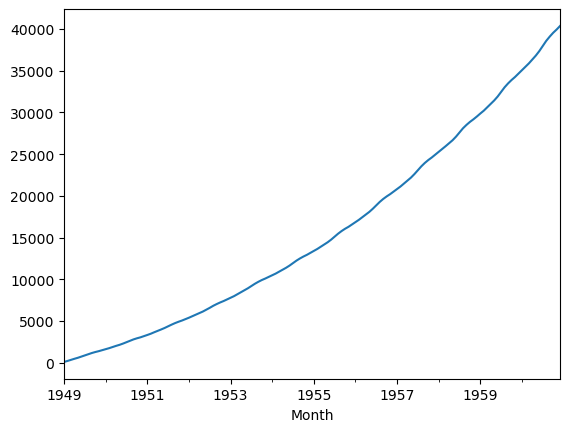

In [91]:
airlines['cumulative_sum'] = airlines['Thousands of Passengers'].expanding().sum()
airlines['cumulative_sum'].plot();

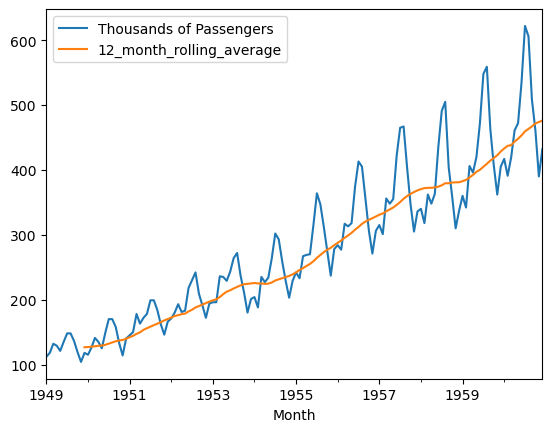

In [92]:
airlines['12_month_rolling_average'] = airlines['Thousands of Passengers'].rolling(window = 12).mean()
airlines[['Thousands of Passengers','12_month_rolling_average']].plot();

# How does time series work

In [93]:
airlines['Thousands of Passengers'].mean().round()

280.0

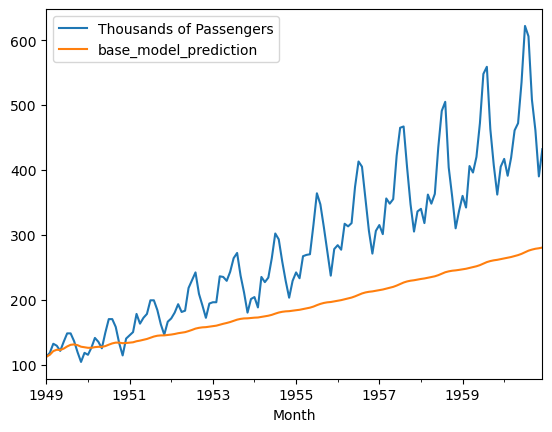

In [94]:
airlines['base_model_prediction'] = airlines['Thousands of Passengers'].expanding().mean()
airlines[['Thousands of Passengers','base_model_prediction']].plot();

# Are some data points more important?

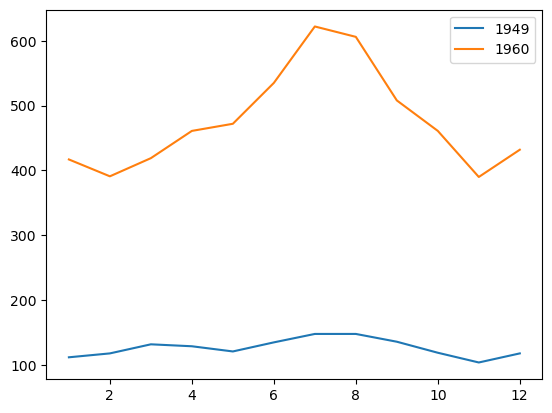

In [95]:
import matplotlib.pyplot as plt

plt.plot(range(1,13), airlines['Thousands of Passengers'].loc['1949'])
plt.plot(range(1,13), airlines['Thousands of Passengers'].loc['1960'])
plt.legend(['1949', '1960']);

# What is simple exponential smoothing?

In [96]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

# ensuring the index is set to a date time and is using MS (Month Start) as the interval
airlines.index = pd.to_datetime(airlines.index)
airlines = airlines.asfreq('MS')

dependent = airlines['Thousands of Passengers'].astype('float')


ses_model = ETSModel(dependent).fit()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    ETS Results                                    
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                  144
Model:                            ETS(ANN)   Log Likelihood                -710.394
Date:                     Wed, 08 Oct 2025   AIC                           1426.788
Time:                             14:14:54   BIC                           1435.697
Sample:                         01-01-1949   HQIC                          1430.408
                              - 12-01-1960   Scale                         1128.569
Covariance Type:                    approx                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.107      9.358      0.000       0.790       1.209
initial_level     111.9841     33.600      3.333      0.001      46.129     177.839
===================================================================================
Ljung-Box (Q):                       15.03   Jarque-Bera (JB):                 5.21
Prob(Q):                              0.00   Prob(JB):                         0.07
Heteroskedasticity (H):               9.29   Skew:                            -0.33
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
"""

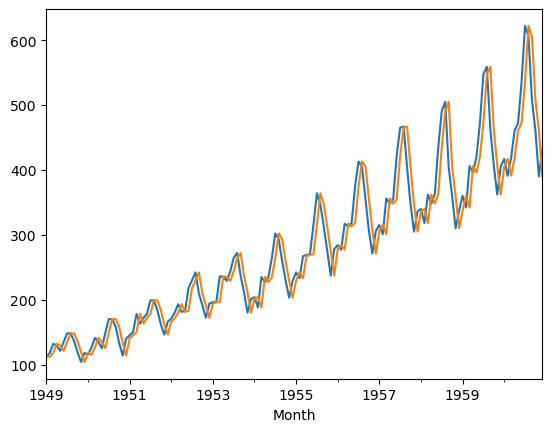

In [97]:
dependent.plot() # this will plot the actual passengers

ses_model.fittedvalues.plot() # this will plot the modelled passengers

ses_model.summary() # this will summarise the model

# What happens next?

In [100]:
forecast = ses_model.get_prediction(start = '1961-01-01', end = '1962-07-01').summary_frame()
forecast

,mean,pi_lower,pi_upper
1961-01-01,431.995801,366.152418,497.839183
1961-02-01,431.995801,338.883852,525.107750
1961-03-01,431.995801,317.959320,546.032282
1961-04-01,431.995801,300.318912,563.672689
1961-05-01,431.995801,284.777300,579.214302
1961-06-01,431.995801,270.726551,593.265051
1961-07-01,431.995801,257.805517,606.186085
1961-08-01,431.995801,245.778887,618.212714
1961-09-01,431.995801,234.483211,629.508390
1961-10-01,431.995801,223.799482,640.192119


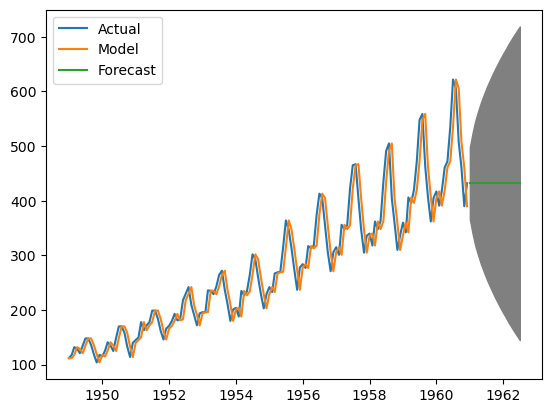

In [106]:
# Plot the actual data
plt.plot(airlines['Thousands of Passengers'])

# Plot the model's fitted values
plt.plot(ses_model.fittedvalues)

# Plot the forecasted mean
plt.plot(forecast['mean'])

# Plot the confidence interval (the shaded area)
plt.fill_between(
    forecast.index,                   # The x-axis
    forecast['pi_lower'],             # The lower confidence interval
    forecast['pi_upper'],             # The upper confidence interval
    color='grey'                      # Set the color
)

# Add a legend to the plot
plt.legend(['Actual', 'Model', 'Forecast']);

# Can we accout for trend and seasonality?

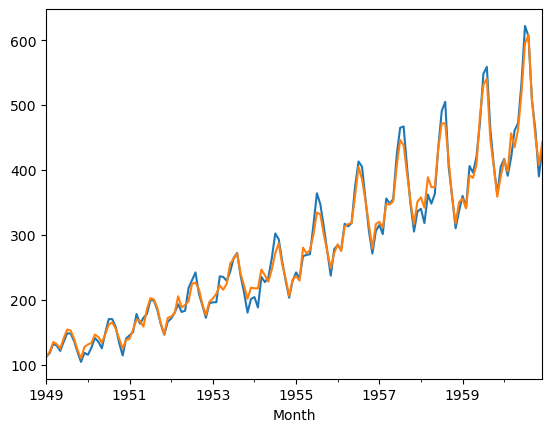

In [108]:
ets_model = ETSModel(dependent, trend = 'add', seasonal = 'add', seasonal_periods = 12).fit()

dependent.plot() # this will plot the actual passengers

ets_model.fittedvalues.plot(); # this will plot the modelled passengers

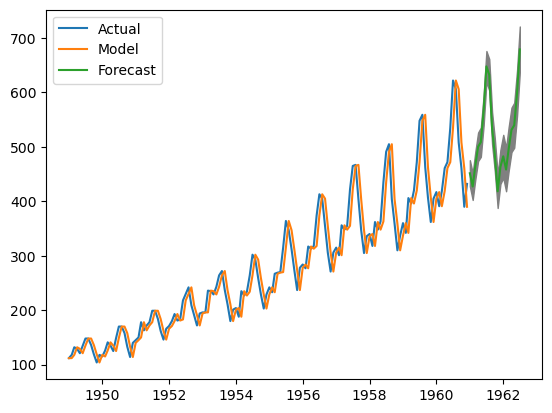

In [110]:
forecast = ets_model.get_prediction(start = '1961-01-01', end = '1962-07-01').summary_frame()

plt.plot(airlines['Thousands of Passengers'])
plt.plot(ses_model.fittedvalues)
plt.plot(forecast['mean'])
plt.fill_between(
    forecast.index,
    forecast['pi_lower'],
    forecast['pi_upper'],
    color='grey'
)
plt.legend(['Actual','Model','Forecast']);